**1.Importing The Dependencies**


In [108]:
# 1. DATA MANIPULATION & ANALYSIS
import numpy as np
import pandas as pd
# 2. DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
#3. DATA PREPROCESSING & SPLITTING
import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_california_housing
# 4. MACHINE LEARNING MODEL
from xgboost import XGBRegressor
# 5. MODEL EVALUATION METRICS
from sklearn import metrics


**2.Importing House Price Prediction Dataset**

In [109]:
house_price_dataset = fetch_california_housing()

In [110]:
print(house_price_dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [111]:
#loading the data set to a pandas dataframe
house_price_dataframe=pd.DataFrame(house_price_dataset.data, columns= house_price_dataset.feature_names)

In [112]:
 #print 5 rows of dataframe
 house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [113]:
house_price_dataframe['price']=house_price_dataset.target

In [114]:
house_price_dataframe.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [115]:
# checking the number of rows and columns in the dataframe
house_price_dataframe.shape

(20640, 9)

In [116]:
#check for missing values
house_price_dataframe.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
price,0


In [117]:
# statistical  measures of the data set
house_price_dataframe.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
price,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


**3.Undersatnding The Correlation Between Various Features In The Dataset**

1.Positive Correlation
2.Negative Correlation

In [118]:
correlation=house_price_dataframe.corr()

<Axes: >

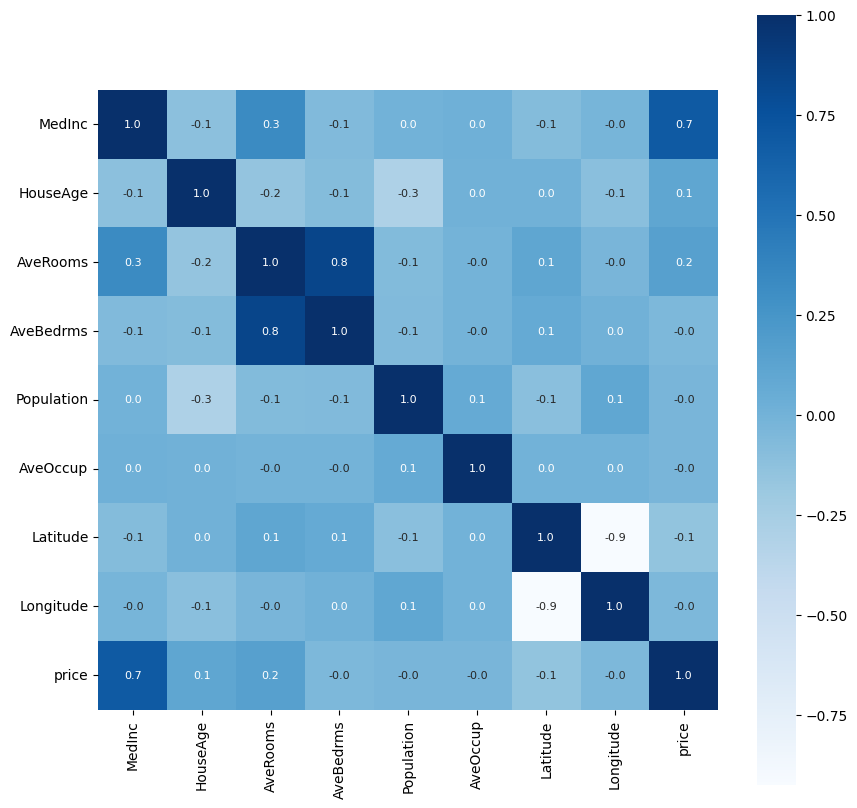

In [119]:
#constructing a heatmap to undersatnd the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True , square=True ,fmt='.1f' , annot=True , annot_kws={'size':8}, cmap='Blues')

**4.Splitting the data and target**

In [120]:
X = house_price_dataframe
Y = house_price_dataset.target

In [121]:
print(X)
print(Y)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  price  
0        -122

**5.Splitting tha data into training data and test data**

In [122]:
X_train , X_test , Y_train, Y_test=train_test_split(X, Y, test_size=0.2 , random_state=2)

In [123]:
print(X.shape,X_train.shape,X_test.shape)

(20640, 9) (16512, 9) (4128, 9)


**6.Model Training**

**_XGRBoost regressor**

In [124]:
#loading the model
model=XGBRegressor()

In [125]:
#training the model with x train
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

**7.Evaluation**

**_prediction on training data**

In [126]:
#accurcy for prediction on training data
training_data_predicition= model.predict(X_train)

In [127]:
print(training_data_predicition)

[0.7222438 2.743267  0.5821849 ... 1.9213579 1.5334225 0.8129889]


In [128]:
#R square error
score_1=metrics.r2_score(Y_train , training_data_predicition)

In [129]:
#MAE
score_2=metrics.mean_absolute_error(Y_train , training_data_predicition)

In [130]:
print("R square error :", score_1)
print("mean absolute error", score_2)

R square error : 0.9999849701637076
mean absolute error 0.0032535701595711734


**_prediction on test data**

**accuracy for prediction on training test data**

In [131]:
test_data_prediction=model.predict(X_test)


In [132]:
score_1=metrics.r2_score(Y_test , test_data_prediction)
score_2=metrics.mean_absolute_error(Y_test , test_data_prediction)

In [133]:
print("R square error :", score_1)
print("MAE:", score_2)

R square error : 0.9999223060929293
MAE: 0.005261440376942009



**8.Visualize the actual prices and predicted prices**

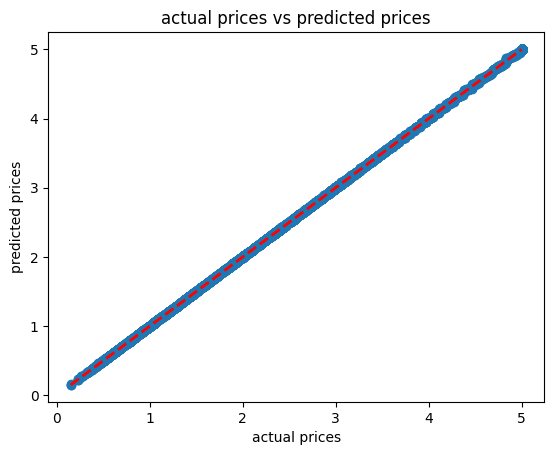

In [134]:
plt.scatter(Y_train, training_data_predicition)

plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--', lw=2)

plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual prices vs predicted prices")
plt.show()